In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("/content/placementdata (1).csv")
df

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,7.5,1,1,2,72,3.9,Yes,No,85,66,NotPlaced
9996,9997,7.4,0,1,0,90,4.8,No,No,84,67,Placed
9997,9998,8.4,1,3,0,70,4.8,Yes,Yes,79,81,Placed
9998,9999,8.9,0,3,2,87,4.8,Yes,Yes,71,85,Placed


In [ ]:
df = df.drop(columns=["StudentID"])

In [ ]:
df

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed
...,...,...,...,...,...,...,...,...,...,...,...
9995,7.5,1,1,2,72,3.9,Yes,No,85,66,NotPlaced
9996,7.4,0,1,0,90,4.8,No,No,84,67,Placed
9997,8.4,1,3,0,70,4.8,Yes,Yes,79,81,Placed
9998,8.9,0,3,2,87,4.8,Yes,Yes,71,85,Placed


In [ ]:
df.isnull().sum()

,0
CGPA,0
Internships,0
Projects,0
Workshops/Certifications,0
AptitudeTestScore,0
SoftSkillsRating,0
ExtracurricularActivities,0
PlacementTraining,0
SSC_Marks,0
HSC_Marks,0


In [ ]:
cat=[]
num=[]
for i in df.columns:
    if df[i].dtype=="O":

        cat.append(i)
    else:
       num.append(i)

In [ ]:
cat

['ExtracurricularActivities', 'PlacementTraining', 'PlacementStatus']

In [ ]:
num

['CGPA',
 'Internships',
 'Projects',
 'Workshops/Certifications',
 'AptitudeTestScore',
 'SoftSkillsRating',
 'SSC_Marks',
 'HSC_Marks']

In [ ]:
df['PlacementStatus'].value_counts()

,count
PlacementStatus,
NotPlaced,5803
Placed,4197


In [ ]:
import matplotlib.pyplot as plt

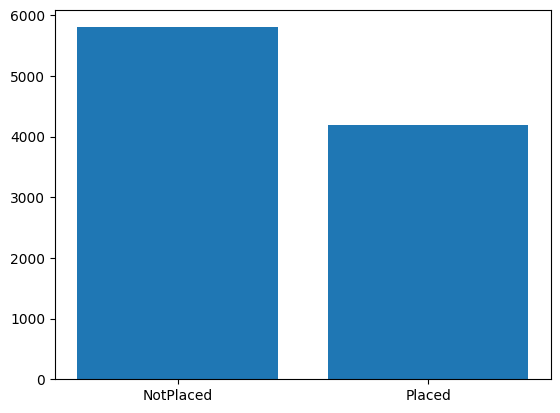

In [ ]:
plt.bar(height=df['PlacementStatus'].value_counts(),x=df['PlacementStatus'].value_counts().index)
plt.show()

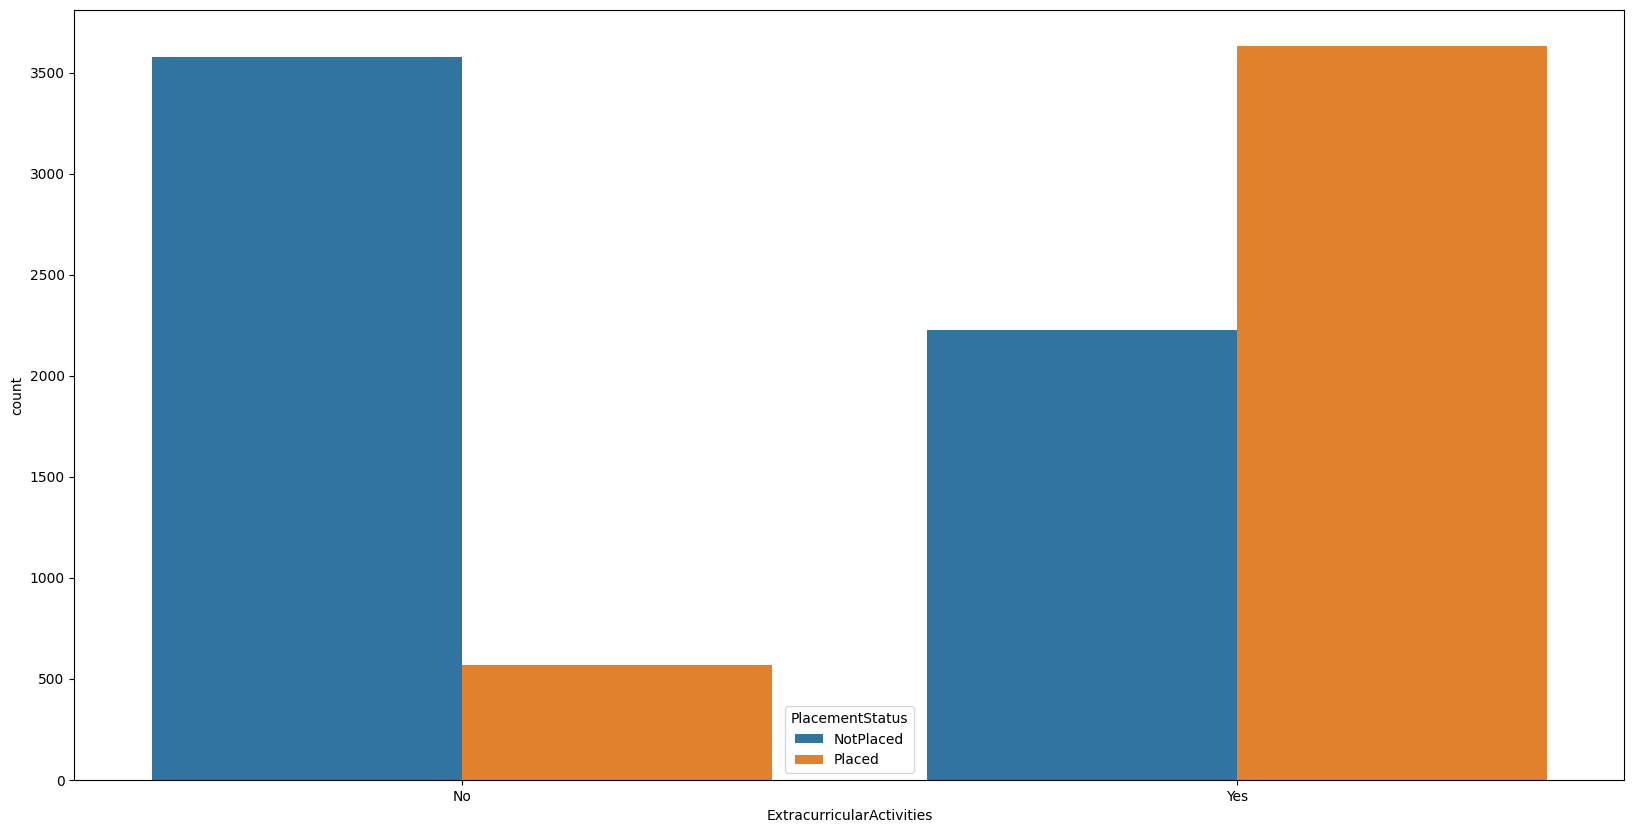

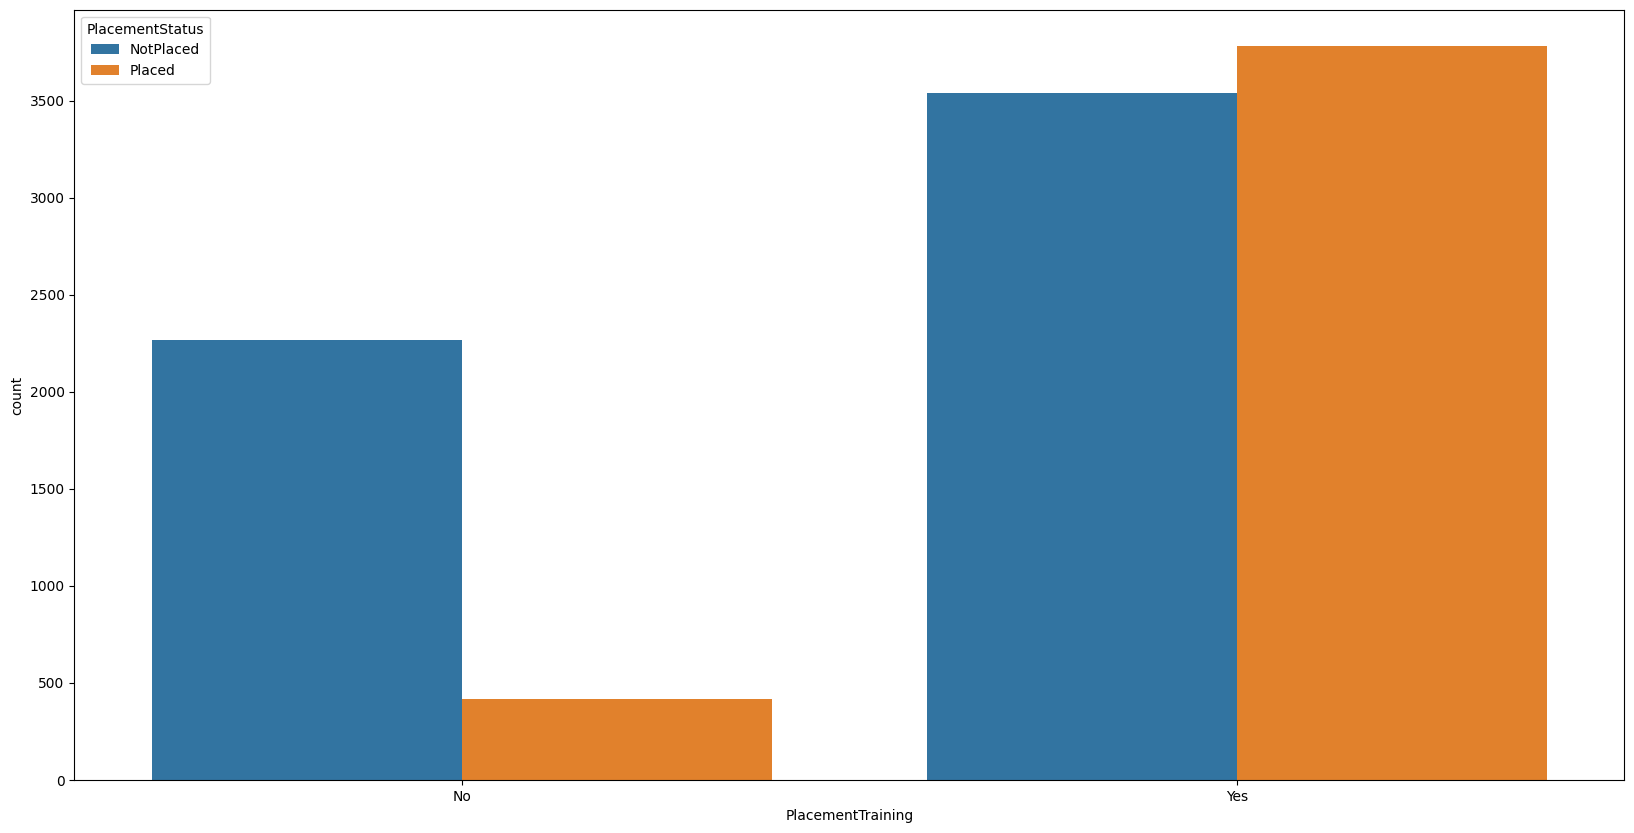

In [ ]:
import seaborn as sns
for i in cat[:-1]:
    plt.figure(figsize=(20,10))
    sns.countplot(data=df, x= i, hue= "PlacementStatus",orient='h', width=0.8)
    plt.show()

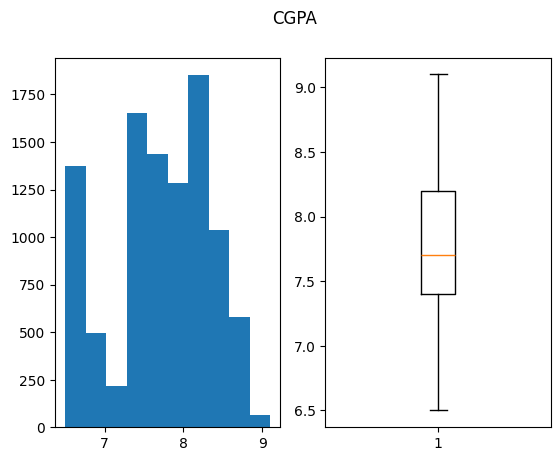

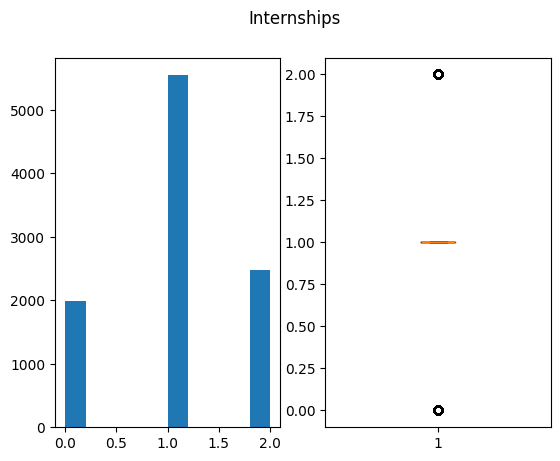

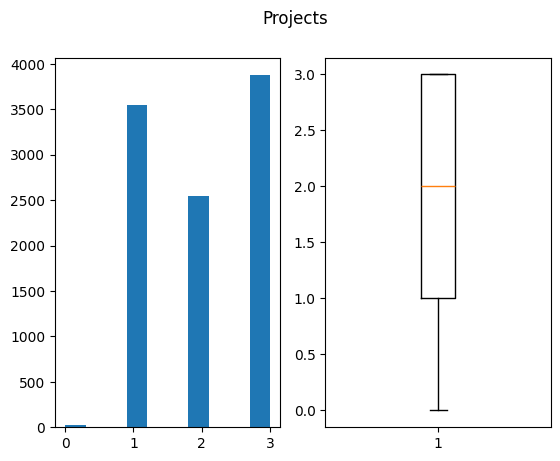

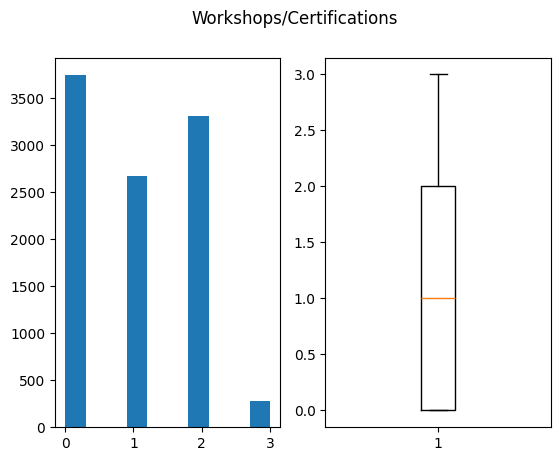

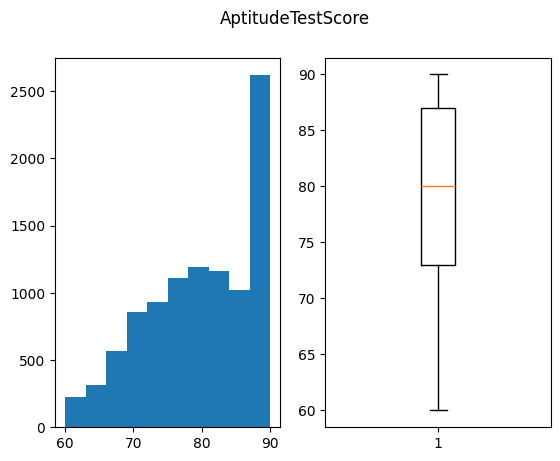

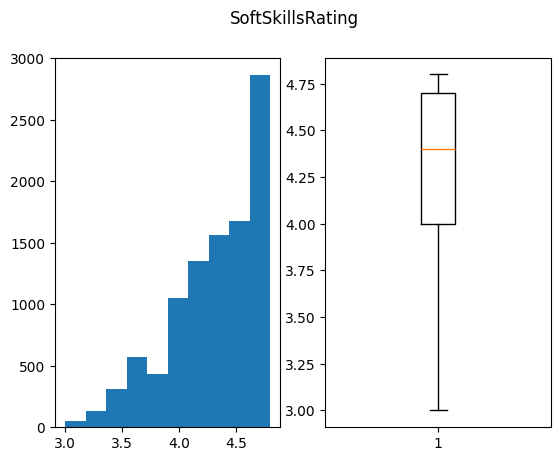

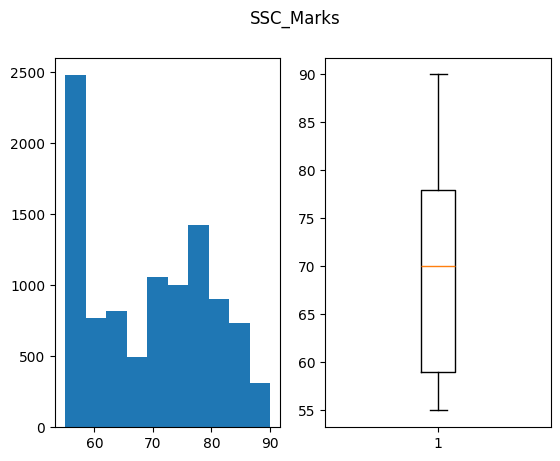

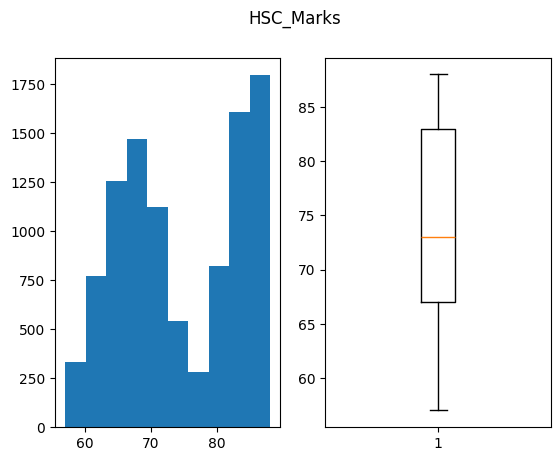

In [ ]:
for i in num:
    fig, ax=plt.subplots(1,2)
    ax[0].hist(df[i])
    ax[1].boxplot(df[i])
    plt.suptitle(i)
    plt.show()

In [ ]:
# Encode categorical columns
from sklearn.preprocessing import LabelEncoder, StandardScaler
le = LabelEncoder()
df["ExtracurricularActivities"] = le.fit_transform(df["ExtracurricularActivities"])  # Yes/No → 1/0


In [ ]:
df["PlacementTraining"] = le.fit_transform(df["PlacementTraining"])


In [ ]:
df["PlacementStatus"] = le.fit_transform(df["PlacementStatus"])  # Placed/Not Placed → 1/0

In [ ]:
df

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,7.5,1,1,1,65,4.4,0,0,61,79,0
1,8.9,0,3,2,90,4.0,1,1,78,82,1
2,7.3,1,2,2,82,4.8,1,0,79,80,0
3,7.5,1,1,2,85,4.4,1,1,81,80,1
4,8.3,1,2,2,86,4.5,1,1,74,88,1
...,...,...,...,...,...,...,...,...,...,...,...
9995,7.5,1,1,2,72,3.9,1,0,85,66,0
9996,7.4,0,1,0,90,4.8,0,0,84,67,1
9997,8.4,1,3,0,70,4.8,1,1,79,81,1
9998,8.9,0,3,2,87,4.8,1,1,71,85,1


In [ ]:
# Create new features
df["Avg_Marks"] = (df["SSC_Marks"] + df["HSC_Marks"]) / 2
df["CGPA_SoftSkill_Interaction"] = df["CGPA"] * df["SoftSkillsRating"]

In [ ]:
df

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus,Avg_Marks,CGPA_SoftSkill_Interaction
0,7.5,1,1,1,65,4.4,0,0,61,79,0,70.0,33.00
1,8.9,0,3,2,90,4.0,1,1,78,82,1,80.0,35.60
2,7.3,1,2,2,82,4.8,1,0,79,80,0,79.5,35.04
3,7.5,1,1,2,85,4.4,1,1,81,80,1,80.5,33.00
4,8.3,1,2,2,86,4.5,1,1,74,88,1,81.0,37.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,7.5,1,1,2,72,3.9,1,0,85,66,0,75.5,29.25
9996,7.4,0,1,0,90,4.8,0,0,84,67,1,75.5,35.52
9997,8.4,1,3,0,70,4.8,1,1,79,81,1,80.0,40.32
9998,8.9,0,3,2,87,4.8,1,1,71,85,1,78.0,42.72


In [ ]:
# Drop original marks if needed
df.drop(columns=["SSC_Marks", "HSC_Marks"], inplace=True)

In [ ]:

# Show sample data
df.head()

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,PlacementStatus,Avg_Marks,CGPA_SoftSkill_Interaction
0,7.5,1,1,1,65,4.4,0,0,0,70.0,33.00
1,8.9,0,3,2,90,4.0,1,1,1,80.0,35.60
2,7.3,1,2,2,82,4.8,1,0,0,79.5,35.04
3,7.5,1,1,2,85,4.4,1,1,1,80.5,33.00
4,8.3,1,2,2,86,4.5,1,1,1,81.0,37.35


In [ ]:
X = df.drop("PlacementStatus", axis=1)
y = df["PlacementStatus"]
X

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,Avg_Marks,CGPA_SoftSkill_Interaction
0,7.5,1,1,1,65,4.4,0,0,70.0,33.00
1,8.9,0,3,2,90,4.0,1,1,80.0,35.60
2,7.3,1,2,2,82,4.8,1,0,79.5,35.04
3,7.5,1,1,2,85,4.4,1,1,80.5,33.00
4,8.3,1,2,2,86,4.5,1,1,81.0,37.35
...,...,...,...,...,...,...,...,...,...,...
9995,7.5,1,1,2,72,3.9,1,0,75.5,29.25
9996,7.4,0,1,0,90,4.8,0,0,75.5,35.52
9997,8.4,1,3,0,70,4.8,1,1,80.0,40.32
9998,8.9,0,3,2,87,4.8,1,1,78.0,42.72


In [ ]:
X= X.values
y= y.values

In [ ]:
X

array([[ 7.5 ,  1.  ,  1.  , ...,  0.  , 70.  , 33.  ],
       [ 8.9 ,  0.  ,  3.  , ...,  1.  , 80.  , 35.6 ],
       [ 7.3 ,  1.  ,  2.  , ...,  0.  , 79.5 , 35.04],
       ...,
       [ 8.4 ,  1.  ,  3.  , ...,  1.  , 80.  , 40.32],
       [ 8.9 ,  0.  ,  3.  , ...,  1.  , 78.  , 42.72],
       [ 8.4 ,  0.  ,  1.  , ...,  0.  , 64.  , 31.92]])

In [ ]:
y

array([0, 1, 0, ..., 1, 1, 0])

In [ ]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Split into training and testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
# Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42)
model.fit(X_train, y_train)

GradientBoostingClassifier(max_depth=4, n_estimators=200, random_state=42)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, precision_score,recall_score,confusion_matrix

In [ ]:
# Predictions
y_pred = model.predict(X_test)

# Evaluation Metrics
print(" Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

 Accuracy: 0.7885
Precision: 0.7521793275217933
Recall: 0.7294685990338164
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.83      0.82      1172
           1       0.75      0.73      0.74       828

    accuracy                           0.79      2000
   macro avg       0.78      0.78      0.78      2000
weighted avg       0.79      0.79      0.79      2000

Confusion Matrix:
 [[973 199]
 [224 604]]


In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

model.fit(X_train, y_train)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [03:21:15] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [ ]:
df["Total_Score"] = df["CGPA"] + df["AptitudeTestScore"] + df["SoftSkillsRating"]
df["Interaction_Feature"] = df["CGPA"] * df["SoftSkillsRating"]


In [ ]:

# Predictions
y_pred = model.predict(X_test)

# Evaluation Metrics
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("🎯 Precision:", precision_score(y_test, y_pred))
print("🔁 Recall:", recall_score(y_test, y_pred))
print("📋 Classification Report:\n", classification_report(y_test, y_pred))
print("🔲 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


✅ Accuracy: 0.7775
🎯 Precision: 0.7355473554735548
🔁 Recall: 0.7222222222222222
📋 Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.82      0.81      1172
           1       0.74      0.72      0.73       828

    accuracy                           0.78      2000
   macro avg       0.77      0.77      0.77      2000
weighted avg       0.78      0.78      0.78      2000

🔲 Confusion Matrix:
 [[957 215]
 [230 598]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, confusion_matrix

# 1. Create and train the model
model = RandomForestClassifier(random_state=0)
model.fit(X_train, y_train)

# 2. Predictions
y_train_predicted = model.predict(X_train)
y_test_predicted = model.predict(X_test)

# 3. Apply custom threshold (optional, only for probability-based classifiers)
predicted_proba = model.predict_proba(X_test)
threshold = 0.6
y_test_predicted = (predicted_proba[:,1] > threshold).astype(int)

# 4. Evaluation
print("📊 Model Performance - Training")
print("Training accuracy:", accuracy_score(y_train, y_train_predicted))
print("Training precision:", precision_score(y_train, y_train_predicted))
print("Training recall:", recall_score(y_train, y_train_predicted))
print("Training confusion_matrix:\n", confusion_matrix(y_train, y_train_predicted))
print("Training classification_report:\n", classification_report(y_train, y_train_predicted))

print("\n📊 Model Performance - Testing")
print("Testing accuracy:", accuracy_score(y_test, y_test_predicted))
print("Testing precision:", precision_score(y_test, y_test_predicted))
print("Testing recall:", recall_score(y_test, y_test_predicted))
print("Testing confusion_matrix:\n", confusion_matrix(y_test, y_test_predicted))
print("Testing classification_report:\n", classification_report(y_test, y_test_predicted))


📊 Model Performance - Training
Training accuracy: 0.99725
Training precision: 0.9943870014771049
Training recall: 0.9991095280498664
Training confusion_matrix:
 [[4612   19]
 [   3 3366]]
Training classification_report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      4631
           1       0.99      1.00      1.00      3369

    accuracy                           1.00      8000
   macro avg       1.00      1.00      1.00      8000
weighted avg       1.00      1.00      1.00      8000


📊 Model Performance - Testing
Testing accuracy: 0.775
Testing precision: 0.7962382445141066
Testing recall: 0.6135265700483091
Testing confusion_matrix:
 [[1042  130]
 [ 320  508]]
Testing classification_report:
               precision    recall  f1-score   support

           0       0.77      0.89      0.82      1172
           1       0.80      0.61      0.69       828

    accuracy                           0.78      2000
   macro avg       0

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier


In [ ]:
# Random Forest model
rf = RandomForestClassifier(random_state=0)

# Hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],          # Number of trees
    'max_depth': [None, 10, 20],         # Tree depth
    'min_samples_split': [2, 5],         # Min samples to split a node
    'min_samples_leaf': [1, 2],          # Min samples at a leaf node
    'max_features': ['sqrt', 'log2']     # Number of features to consider at each split
}


In [ ]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,                      # 5-fold cross-validation
    scoring='accuracy',        # You can also use 'f1', 'roc_auc', etc.
    n_jobs=-1,                 # Use all available CPU cores
    verbose=1
)


In [ ]:
grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=0), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy', verbose=1)

In [ ]:
print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_


Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


In [ ]:
grid_search.best_score_

np.float64(0.79825)

In [ ]:
model= RandomForestClassifier(max_depth=10, max_features= 'sqrt', min_samples_leaf = 2, min_samples_split=2, n_estimators= 100)
model.fit(X_train, y_train)
y_train_predicted= model.predict(X_train)
y_test_predicted= model.predict(X_test)

In [ ]:
print("Model Performance")
print("Tranining accuracy:", accuracy_score(y_train, y_train_predicted))
#print("Tranining precision:", precision_score(y_train, y_train_predicted))
#print("Tranining recall:", recall_score(y_train, y_train_predicted))
print()
print(confusion_matrix(y_train, y_train_predicted))
print()
print()
print(classification_report(y_train, y_train_predicted))

Model Performance
Tranining accuracy: 0.8785

[[4244  387]
 [ 585 2784]]


              precision    recall  f1-score   support

           0       0.88      0.92      0.90      4631
           1       0.88      0.83      0.85      3369

    accuracy                           0.88      8000
   macro avg       0.88      0.87      0.87      8000
weighted avg       0.88      0.88      0.88      8000



In [ ]:
print("Model Performance")
print("Testing accuracy:", accuracy_score(y_test, y_test_predicted))
#print("Testing precision:", precision_score(y_test, y_test_predicted))
#print("Testing recall:", recall_score(y_test, y_test_predicted))
print()
print(confusion_matrix(y_test, y_test_predicted))
print()
print()
print(classification_report(y_test, y_test_predicted))

Model Performance
Testing accuracy: 0.7855

[[975 197]
 [232 596]]


              precision    recall  f1-score   support

           0       0.81      0.83      0.82      1172
           1       0.75      0.72      0.74       828

    accuracy                           0.79      2000
   macro avg       0.78      0.78      0.78      2000
weighted avg       0.78      0.79      0.78      2000



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, classification_report, f1_score
)

# 1. Create and train the model
model = LogisticRegression(solver='liblinear', random_state=0)
model.fit(X_train, y_train)

# 2. Predictions with custom threshold
threshold = 0.6

# Train set predictions
predicted_proba_train = model.predict_proba(X_train)
y_train_predicted = (predicted_proba_train[:,1] > threshold).astype(int)

# Test set predictions
predicted_proba_test = model.predict_proba(X_test)
y_test_predicted = (predicted_proba_test[:,1] > threshold).astype(int)

# 3. Evaluation
print("📊 Model Performance - Training")
print("Accuracy:", accuracy_score(y_train, y_train_predicted))
print("Precision:", precision_score(y_train, y_train_predicted))
print("Recall:", recall_score(y_train, y_train_predicted))
print("F1 Score:", f1_score(y_train, y_train_predicted))
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_predicted))
print("Classification Report:\n", classification_report(y_train, y_train_predicted))

print("\n📊 Model Performance - Testing")
print("Accuracy:", accuracy_score(y_test, y_test_predicted))
print("Precision:", precision_score(y_test, y_test_predicted))
print("Recall:", recall_score(y_test, y_test_predicted))
print("F1 Score:", f1_score(y_test, y_test_predicted))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_predicted))
print("Classification Report:\n", classification_report(y_test, y_test_predicted))


📊 Model Performance - Training
Accuracy: 0.8
Precision: 0.8044750430292599
Recall: 0.6936776491540516
F1 Score: 0.7449792795664648
Confusion Matrix:
 [[4063  568]
 [1032 2337]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.88      0.84      4631
           1       0.80      0.69      0.74      3369

    accuracy                           0.80      8000
   macro avg       0.80      0.79      0.79      8000
weighted avg       0.80      0.80      0.80      8000


📊 Model Performance - Testing
Accuracy: 0.7875
Precision: 0.7748976807639836
Recall: 0.6859903381642513
F1 Score: 0.7277386290839206
Confusion Matrix:
 [[1007  165]
 [ 260  568]]
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.86      0.83      1172
           1       0.77      0.69      0.73       828

    accuracy                           0.79      2000
   macro avg       0.78      0.77      0.78      2

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, classification_report, f1_score
)

# 1. Define the model
log_reg = LogisticRegression(solver='liblinear', random_state=0)

# 2. Define hyperparameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10],     # Regularization strength
    'penalty': ['l1', 'l2'],     # Regularization type
}

# 3. Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,                        # 5-fold cross-validation
    scoring='f1',                # Optimize for F1 score
    n_jobs=-1,
    verbose=1
)

# 4. Fit the model
grid_search.fit(X_train, y_train)

# 5. Best model and parameters
print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters: {'C': 0.01, 'penalty': 'l2'}


In [ ]:
grid_search.best_score_

np.float64(0.7643170169659521)

In [ ]:
model= LogisticRegression(C= 0.01, penalty= 'l2')
model.fit(X_train, y_train)
y_train_predicted= model.predict(X_train)
y_test_predicted= model.predict(X_test)

In [ ]:
print("Model Performance")
print("Tranining accuracy:", accuracy_score(y_train, y_train_predicted))
#print("Tranining precision:", precision_score(y_train, y_train_predicted))
#print("Tranining recall:", recall_score(y_train, y_train_predicted))
print()
print(confusion_matrix(y_train, y_train_predicted))
print()
print()
print(classification_report(y_train, y_train_predicted))

Model Performance
Tranining accuracy: 0.80075

[[3837  794]
 [ 800 2569]]


              precision    recall  f1-score   support

           0       0.83      0.83      0.83      4631
           1       0.76      0.76      0.76      3369

    accuracy                           0.80      8000
   macro avg       0.80      0.80      0.80      8000
weighted avg       0.80      0.80      0.80      8000



In [ ]:
print("Model Performance")
print("Testing accuracy:", accuracy_score(y_test, y_test_predicted))
#print("Testing precision:", precision_score(y_test, y_test_predicted))
#print("Testing recall:", recall_score(y_test, y_test_predicted))
print()
print(confusion_matrix(y_test, y_test_predicted))
print()
print()
print(classification_report(y_test, y_test_predicted))

Model Performance
Testing accuracy: 0.793

[[953 219]
 [195 633]]


              precision    recall  f1-score   support

           0       0.83      0.81      0.82      1172
           1       0.74      0.76      0.75       828

    accuracy                           0.79      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.79      0.79      0.79      2000



In [ ]:
def predict_placement(cgpa, internships, projects, certifications, aptitude_score,
                      soft_skills, extracurricular, training, avg_marks):
    interaction = cgpa * soft_skills
    input_data = np.array([[cgpa, internships, projects, certifications, aptitude_score,
                            soft_skills, 1 if extracurricular == "Yes" else 0,
                            1 if training == "Yes" else 0, avg_marks, interaction]])
    input_scaled = scaler.transform(input_data)
    prediction = model.predict(input_scaled)[0]
    return "🎉 The student is likely to be Placed!" if prediction == 1 else "❌ The student is likely *Not* to be Placed."


In [ ]:
!pip install gradio


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.2/322.2 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 4.3 MB/s eta 0:00:00


In [ ]:
import gradio as gr

In [ ]:
with gr.Blocks(theme=gr.themes.Soft()) as interface:
    gr.Markdown("## 🎓 Placement Predictor App ")
    gr.Markdown("Enter student details below to get placement prediction:")

    with gr.Row():
        cgpa = gr.Slider(4.0, 10.0, step=0.1, label="📚 CGPA")
        soft_skills = gr.Slider(1.0, 5.0, step=0.1, label="🗣️ Soft Skills Rating")

    with gr.Row():
        internships = gr.Slider(0, 5, step=1, label="💼 Internships")
        projects = gr.Slider(0, 10, step=1, label="🧠 Projects")

    with gr.Row():
        certifications = gr.Slider(0, 10, step=1, label="📄 Certifications")
        aptitude_score = gr.Slider(0, 100, step=1, label="🧠 Aptitude Score")

    with gr.Row():
        extracurricular = gr.Radio(["Yes", "No"], label="🎭 Extracurricular Activities")
        training = gr.Radio(["Yes", "No"], label="🎯 Placement Training Done")
        avg_marks = gr.Slider(30, 100, step=1, label="📊 Average SSC + HSC Marks")

    predict_btn = gr.Button("🚀 Predict Placement")
    output = gr.Textbox(label="📢 Prediction Result")

    predict_btn.click(
        predict_placement,
        inputs=[cgpa, internships, projects, certifications, aptitude_score,
                soft_skills, extracurricular, training, avg_marks],
        outputs=output
    )

interface.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://463efbda81274349a4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
